# Brain MRI Tissue Segmentation — Multi-Class Semantic Segmentation
## VGG16 + UNet | 4-Class (Background / CSF / Grey Matter / White Matter) | MRBrainS18 Dataset

**Dataset:** MRBrainS18 Challenge Dataset — 7 labeled training subjects, multi-sequence MRI (T1, FLAIR, IR). Only the `training` split is used since the `test` split has no publicly released segmentation labels.

**Label Remapping:** MRBrainS18 uses 9 classes which are consolidated into 4 tissue classes:
- 0 → Background
- 1, 2, 8 → Grey Matter (cortical GM + basal ganglia + brainstem/cerebellum)
- 3, 4 → White Matter (WM + WM lesions)
- 5, 6, 7 → CSF (ventricular CSF + vessels + external CSF)

**Training Notes:**
- Only 7 labeled subjects are available; therefore, every slice (`step=1`) is used to maximize the training dataset.
- Strong data augmentation is applied to improve model generalization.
- EarlyStopping is disabled so the model trains for the full configured number of epochs.

## 1. Import Libraries

In [7]:
import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, UpSampling2D, concatenate,
    BatchNormalization, Dropout, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

!pip install nibabel -q
import nibabel as nib

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [8]:
# ─── Paths ────────────────────────────────────────────────────────────────────
TRAIN_ROOT = '/kaggle/input/datasets/maheswarimudadla/training/training'
# Note: test split excluded — no public segmentation labels available

PROCESSED_DIR  = 'mrbrains_processed'
IMAGE_FOLDER   = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER    = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR  = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR   = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR  = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 8    # smaller batch — fewer total slices than OASIS/IBSR
EPOCHS      = 100
SEED        = 42
TEST_SPLIT  = 0.20  # slightly larger test split given small dataset
NUM_CLASSES = 4
CLASS_NAMES = ['Background', 'CSF', 'Grey Matter', 'White Matter']

# ─── MRBrainS18 label remapping ───────────────────────────────────────────────
# Original 9 classes → 4 standard tissue classes (matches OASIS-1 and IBSR)
MRBRAINS_REMAP = {
    0: 0,  # Background
    1: 2,  # Cortical Grey Matter → GM
    2: 2,  # Basal Ganglia → GM
    3: 3,  # White Matter → WM
    4: 3,  # White Matter Lesions → WM
    5: 1,  # Ventricular CSF → CSF
    6: 1,  # Vessels/Choroid Plexus → CSF
    7: 1,  # External CSF/Sulci → CSF
    8: 2,  # Brainstem + Cerebellum → GM
}

print('Config set ✓')
print('Label remapping:', MRBRAINS_REMAP)

Config set ✓
Label remapping: {0: 0, 1: 2, 2: 2, 3: 3, 4: 3, 5: 1, 6: 1, 7: 1, 8: 2}


## 3. Extract 2D Slices — Remap 9 Classes to 4

In [9]:
for d in [IMAGE_FOLDER, MASK_FOLDER,
          TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

print('Directories ready ✓')

Directories ready ✓


In [10]:
import os
import shutil
import cv2
import numpy as np
import nibabel as nib
from tqdm import tqdm

# -----------------------------------------------------------------------------
# Label remapping (Modify according to your experiment)
# -----------------------------------------------------------------------------
# Example:
# 0 -> Background
# 1 -> CSF
# 2 -> Gray Matter
# 3 -> White Matter

MRBRAINS_REMAP = {
    0: 0,
    1: 1,
    2: 2,
    3: 3,
    4: 0,
    5: 0,
    6: 0,
    7: 0,
    8: 0
}

# -----------------------------------------------------------------------------
# Normalize MRI slice to 0-255
# -----------------------------------------------------------------------------
def normalize_slice(arr):
    arr = arr.astype(np.float32)
    mn, mx = arr.min(), arr.max()

    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)

    arr = (arr - mn) / (mx - mn)
    arr = (arr * 255).astype(np.uint8)

    return arr

# -----------------------------------------------------------------------------
# Remap segmentation labels
# -----------------------------------------------------------------------------
def remap_labels(seg_arr, remap_dict):
    out = np.zeros_like(seg_arr, dtype=np.uint8)

    for old_label, new_label in remap_dict.items():
        out[seg_arr == old_label] = new_label

    return out

# -----------------------------------------------------------------------------
# Extract slices
# -----------------------------------------------------------------------------
def extract_slices_mrbrains(subject_dir,
                            subject_name,
                            img_out,
                            mask_out,
                            step=1):

    # Use REGISTERED T1 (same space as segmentation)
    t1_path = os.path.join(subject_dir, "orig", "reg_T1.nii")
    seg_path = os.path.join(subject_dir, "segm.nii")

    # Fallback to .nii.gz if needed
    if not os.path.exists(t1_path):
        t1_path = os.path.join(subject_dir, "orig", "reg_T1.nii.gz")

    if not os.path.exists(seg_path):
        seg_path = os.path.join(subject_dir, "segm.nii.gz")

    if not os.path.exists(t1_path) or not os.path.exists(seg_path):
        print(f"Skipping {subject_name}: files missing.")
        return 0

    brain_vol = np.squeeze(nib.load(t1_path).get_fdata())
    seg_vol = np.squeeze(nib.load(seg_path).get_fdata())

    print(f"{subject_name}: Brain {brain_vol.shape} | Seg {seg_vol.shape}")

    saved = 0

    num_slices = brain_vol.shape[2]

    for i in range(0, num_slices, step):

        brain_slice = brain_vol[:, :, i]
        seg_slice = seg_vol[:, :, i]

        # Skip completely empty masks
        if np.count_nonzero(seg_slice) == 0:
            continue

        img = normalize_slice(brain_slice)

        mask = remap_labels(
            np.round(seg_slice).astype(np.uint8),
            MRBRAINS_REMAP
        )

        filename = f"{subject_name}_slice_{i:03d}.png"

        cv2.imwrite(
            os.path.join(img_out, filename),
            img
        )

        cv2.imwrite(
            os.path.join(mask_out, filename),
            mask
        )

        saved += 1

    return saved

# -----------------------------------------------------------------------------
# Clear previous extracted data
# -----------------------------------------------------------------------------
for folder in [IMAGE_FOLDER, MASK_FOLDER]:

    if os.path.exists(folder):
        shutil.rmtree(folder)

    os.makedirs(folder)

# -----------------------------------------------------------------------------
# Get all subjects
# -----------------------------------------------------------------------------
subject_folders = sorted([
    d for d in os.listdir(TRAIN_ROOT)
    if os.path.isdir(os.path.join(TRAIN_ROOT, d))
])

print("Subjects found:")
print(subject_folders)
print()

# -----------------------------------------------------------------------------
# Extract all slices
# -----------------------------------------------------------------------------
total_slices = 0

for subject in tqdm(subject_folders, desc="Extracting"):

    subject_dir = os.path.join(TRAIN_ROOT, subject)

    total_slices += extract_slices_mrbrains(
        subject_dir,
        subject,
        IMAGE_FOLDER,
        MASK_FOLDER,
        step=1
    )

# -----------------------------------------------------------------------------
# Summary
# -----------------------------------------------------------------------------
print("\nExtraction Completed")
print("-----------------------------")
print("Total saved slices :", total_slices)
print("Images :", len(os.listdir(IMAGE_FOLDER)))
print("Masks  :", len(os.listdir(MASK_FOLDER)))

Subjects found:
['1', '14', '27', '29', '4', '5', '7']



Extracting:   0%|          | 0/7 [00:00<?, ?it/s]

1: Brain (240, 240, 48) | Seg (240, 240, 48)


Extracting:  14%|█▍        | 1/7 [00:00<00:00,  9.78it/s]

14: Brain (240, 240, 48) | Seg (240, 240, 48)
27: Brain (240, 240, 48) | Seg (240, 240, 48)


...

5: Brain (240, 240, 48) | Seg (240, 240, 48)


Extracting:  86%|████████▌ | 6/7 [00:00<00:00,  8.62it/s]

7: Brain (240, 240, 48) | Seg (240, 240, 48)


Extracting: 100%|██████████| 7/7 [00:00<00:00,  8.89it/s]


Extraction Completed
-----------------------------
Total saved slices : 319
Images : 319
Masks  : 319


In [11]:
import nibabel as nib
import os

subject_dir = os.path.join(TRAIN_ROOT, "1")

for f in [
    "orig/T1.nii",
    "orig/reg_T1.nii",
    "orig/FLAIR.nii",
    "orig/reg_IR.nii",
    "segm.nii"
]:
    p = os.path.join(subject_dir, f)
    img = nib.load(p)
    print(f, img.shape)

orig/T1.nii (256, 256, 192)
orig/reg_T1.nii (240, 240, 48)
orig/FLAIR.nii (240, 240, 48)
orig/reg_IR.nii (240, 240, 48)
segm.nii (240, 240, 48)


## 4. Verify Label Remapping & Visualize

In [12]:
sample_mask_files = random.sample(os.listdir(MASK_FOLDER), min(20, len(os.listdir(MASK_FOLDER))))
all_vals = set()
for f in sample_mask_files:
    m = cv2.imread(os.path.join(MASK_FOLDER, f), cv2.IMREAD_GRAYSCALE)
    all_vals.update(np.unique(m).tolist())

print('Unique label values found across sample masks:', sorted(all_vals))
print('Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)')

Unique label values found across sample masks: [0, 1, 2, 3]
Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)


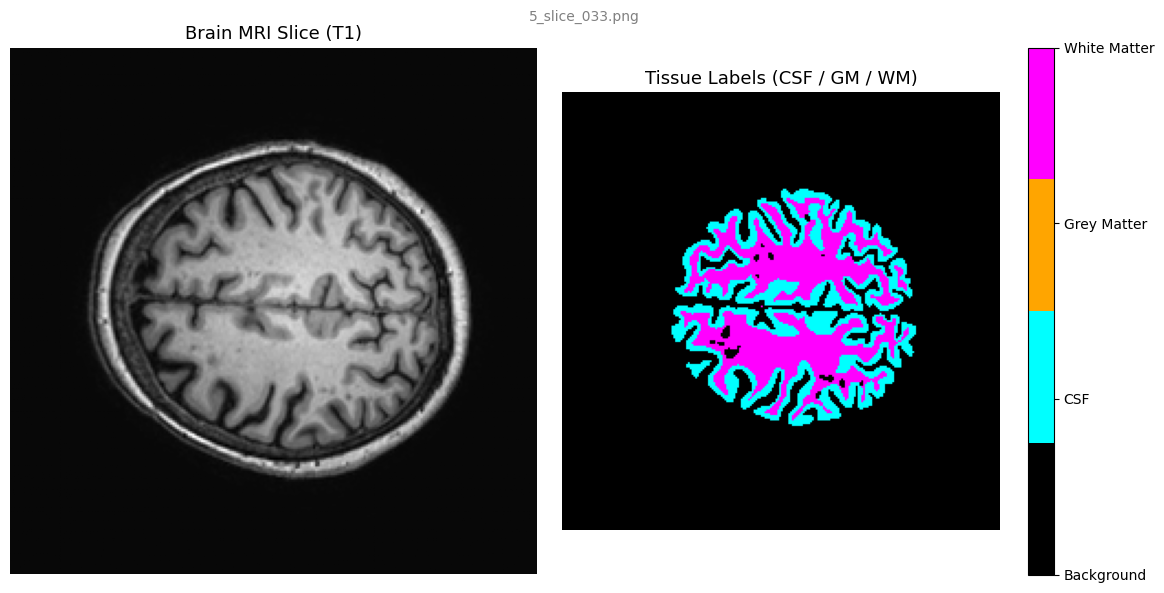

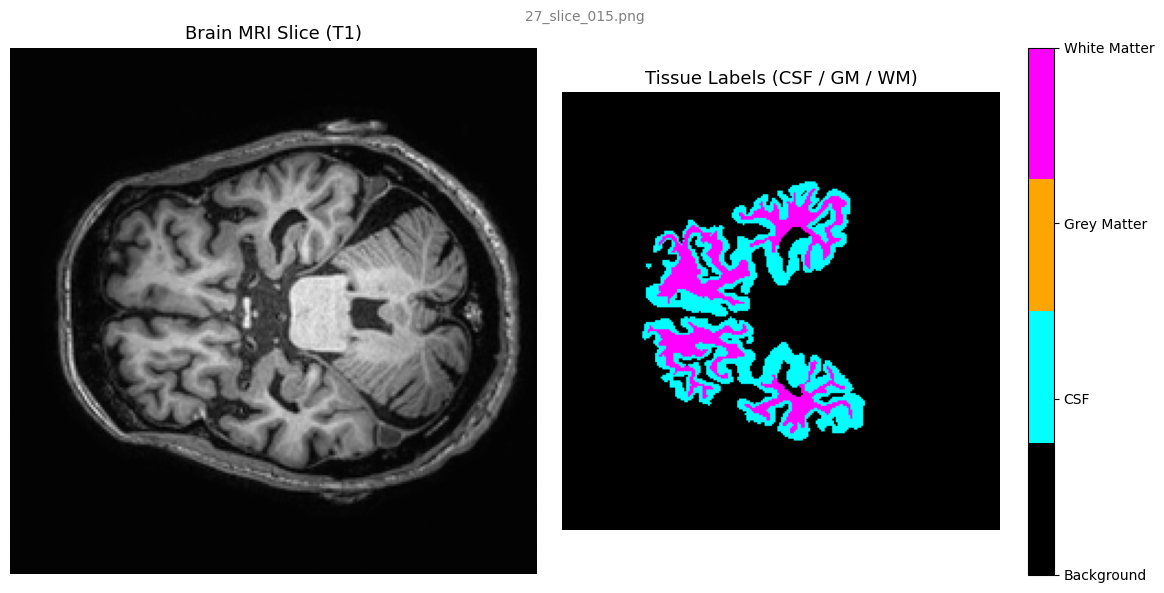

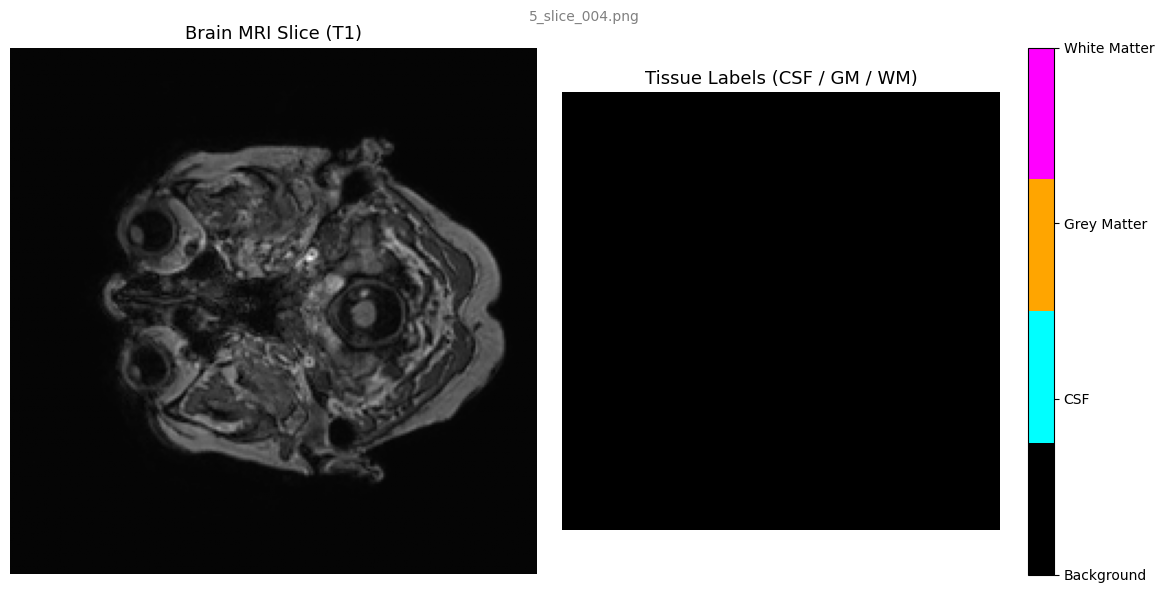

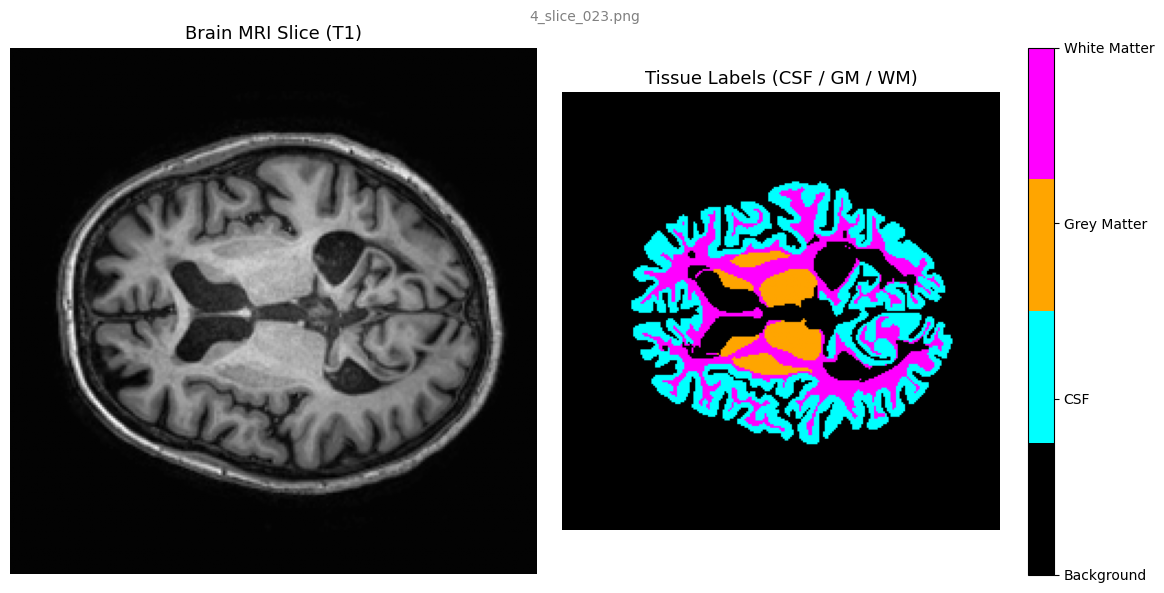

In [13]:
CLASS_COLORS = ['black', 'cyan', 'orange', 'magenta']
cmap_classes = mcolors.ListedColormap(CLASS_COLORS)

def visualize_sample(image_name):
    img  = cv2.imread(os.path.join(IMAGE_FOLDER, image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(MASK_FOLDER,  image_name), cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Brain MRI Slice (T1)', fontsize=13)

    im = axes[1].imshow(mask, cmap=cmap_classes, vmin=0, vmax=NUM_CLASSES - 1)
    axes[1].set_title('Tissue Labels (CSF / GM / WM)', fontsize=13)
    cbar = plt.colorbar(im, ax=axes[1], ticks=range(NUM_CLASSES))
    cbar.ax.set_yticklabels(CLASS_NAMES)

    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()


all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample(random.choice(all_images))

## 5. Train / Test Split

In [14]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])

assert images == masks, 'Image-mask mismatch!'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')

Train: 255  |  Test: 64


Files copied ✓


## 6. tf.data Pipeline — with stronger augmentation (small dataset)

In [15]:
def load_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.int32)
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.one_hot(mask, depth=NUM_CLASSES)
    mask = tf.cast(mask, tf.float32)
    return img, mask


def augment(img, mask):
    # Stronger augmentation since dataset is small (7 subjects)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask


def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])
    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)

print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes → images:', imgs.shape, ' masks:', masks.shape)

I0000 00:00:1783276880.115152      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets ready ✓
Batch shapes → images: (8, 224, 224, 3)  masks: (8, 224, 224, 4)


## 7. Model — VGG16 Encoder + UNet Decoder, 4-class softmax output

In [16]:
def conv_block(x, filters, name_prefix):
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c1')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = Activation('relu', name=f'{name_prefix}_act1')(x)
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c2')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn2')(x)
    x = Activation('relu', name=f'{name_prefix}_act2')(x)
    return x


def decoder_block(x, skip, filters, name_prefix):
    x = UpSampling2D((2, 2), name=f'{name_prefix}_up')(x)
    x = concatenate([x, skip], name=f'{name_prefix}_cat')
    x = Dropout(0.2, name=f'{name_prefix}_drop')(x)
    x = conv_block(x, filters, name_prefix)
    return x


def build_vgg16_unet_multiclass(input_shape=(224, 224, 3), num_classes=4, freeze_encoder=True):
    inputs = Input(shape=input_shape, name='input')
    base = VGG16(include_top=False, weights='imagenet', input_tensor=inputs)

    if freeze_encoder:
        for layer in base.layers:
            layer.trainable = False

    s1 = base.get_layer('block1_conv2').output
    s2 = base.get_layer('block2_conv2').output
    s3 = base.get_layer('block3_conv3').output
    s4 = base.get_layer('block4_conv3').output
    b  = base.get_layer('block5_conv3').output

    d4 = decoder_block(b,  s4, 512, 'dec4')
    d3 = decoder_block(d4, s3, 256, 'dec3')
    d2 = decoder_block(d3, s2, 128, 'dec2')
    d1 = decoder_block(d2, s1,  64, 'dec1')

    output = Conv2D(num_classes, (1, 1), activation='softmax', name='output')(d1)
    model = Model(inputs=inputs, outputs=output, name='VGG16_UNet_MultiClass_MRBrainS18')
    return model


model = build_vgg16_unet_multiclass(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
print('Model built ✓')
print(f'Total parameters     : {model.count_params():,}')
print(f'Trainable parameters : {sum([K.count_params(w) for w in model.trainable_weights]):,}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Model built ✓
Total parameters     : 24,899,012
Trainable parameters : 10,180,484


## 8. Custom Metrics & Loss

In [17]:
def dice_coefficient_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    union = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0)
    return K.mean((2.0 * intersection + smooth) / (union + smooth))

def dice_loss_multiclass(y_true, y_pred):
    return 1.0 - dice_coefficient_multiclass(y_true, y_pred)

def iou_score_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    total = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0) - intersection
    return K.mean((intersection + smooth) / (total + smooth))

def csf_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 1]; p = y_pred[..., 1]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def gm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 2]; p = y_pred[..., 2]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def wm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 3]; p = y_pred[..., 3]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def pixel_accuracy_multiclass(y_true, y_pred):
    return K.mean(K.cast(K.equal(K.argmax(y_true, axis=-1), K.argmax(y_pred, axis=-1)), K.floatx()))

def combined_loss_multiclass(y_true, y_pred):
    return dice_loss_multiclass(y_true, y_pred) + tf.keras.losses.categorical_crossentropy(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss_multiclass,
    metrics=[dice_coefficient_multiclass, iou_score_multiclass,
             pixel_accuracy_multiclass, csf_iou, gm_iou, wm_iou]
)
print('Model compiled ✓')

Model compiled ✓


## 9. Model Summary

In [18]:
model.summary()
try:
    tf.keras.utils.plot_model(model, to_file='vgg16_unet_mrbrains_architecture.png',
                               show_shapes=True, show_layer_names=True, dpi=64)
    print('Architecture diagram saved ✓')
except Exception as e:
    print('Architecture plot skipped:', str(e)[:100])

Model: "VGG16_UNet_MultiClass_MRBrainS18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 24,899,012 (94.98 MB)

 Trainable params: 10,180,484 (38.84 MB)

 Non-trainable params: 14,718,528 (56.15 MB)

Architecture diagram saved ✓


## 10. Callbacks (EarlyStopping disabled)

In [19]:
def decode_mask(onehot_mask):
    return tf.argmax(onehot_mask, axis=-1)

def colorize_mask(label_map):
    colors = np.array([[0,0,0],[0,255,255],[255,165,0],[255,0,255]], dtype=np.uint8)
    return colors[np.array(label_map).astype(int)]

def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            fig, axes = plt.subplots(1, 3, figsize=(13, 4))
            axes[0].imshow(imgs[i].numpy());                              axes[0].set_title('Input MRI')
            axes[1].imshow(colorize_mask(decode_mask(masks[i]).numpy())); axes[1].set_title('Ground Truth')
            axes[2].imshow(colorize_mask(decode_mask(preds[i]).numpy())); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout(); plt.show()

class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')

logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model_vgg16unet_mrbrains.keras', verbose=1,
                               save_best_only=True, monitor='val_iou_score_multiclass', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    # EarlyStopping intentionally removed
]
print('Callbacks ready ✓ (no EarlyStopping — will run all', EPOCHS, 'epochs)')

Callbacks ready ✓ (no EarlyStopping — will run all 100 epochs)


## 11. Initial Predictions (before training)

Predictions before training:


I0000 00:00:1783276895.146055     144 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


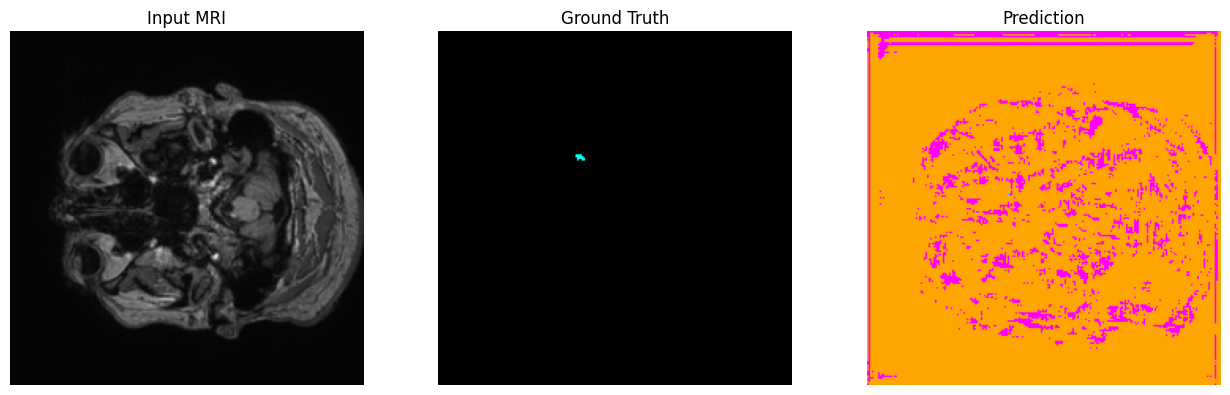

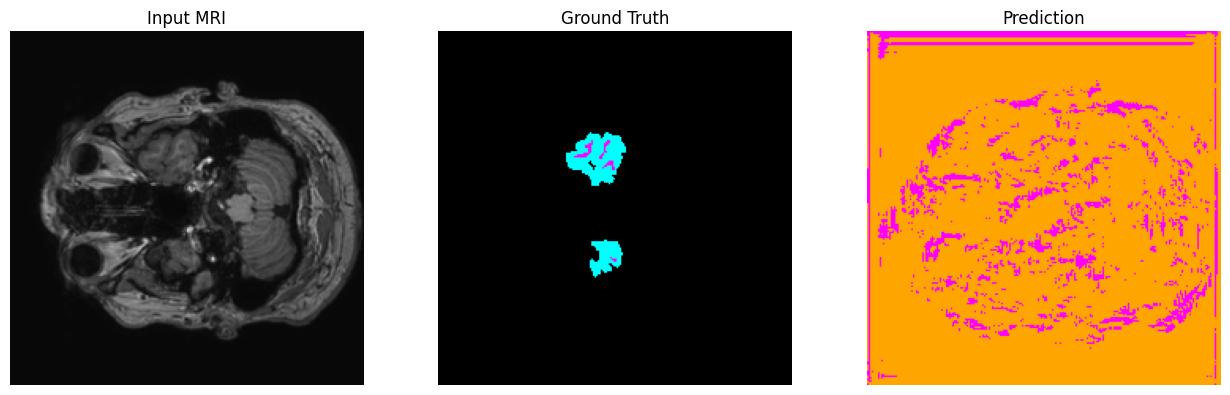

In [20]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)

## 12. Training

Steps per epoch  : 31
Validation steps : 8
Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - csf_iou: 0.0817 - dice_coefficient_multiclass: 0.1571 - gm_iou: 0.0043 - iou_score_multiclass: 0.0929 - loss: 2.7044 - pixel_accuracy_multiclass: 0.2090 - wm_iou: 0.0638
Epoch 1: val_iou_score_multiclass improved from None to 0.07777, saving model to best_model_vgg16unet_mrbrains.keras

Epoch 1: finished saving model to best_model_vgg16unet_mrbrains.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 34s 387ms/step - csf_iou: 0.1086 - dice_coefficient_multiclass: 0.2015 - gm_iou: 0.0043 - iou_score_multiclass: 0.1250 - loss: 2.3996 - pixel_accuracy_multiclass: 0.3619 - wm_iou: 0.0924 - val_csf_iou: 0.1412 - val_dice_coefficient_multiclass: 0.1358 - val_gm_iou: 0.0016 - val_iou_score_multiclass: 0.0778 - val_loss: 11.6437 - val_pixel_accuracy_multiclass: 0.2396 - val_wm_iou: 0.0121 - learning_rate: 1.0000e-04
Epoch 2/100


2026-07-05 18:42:15.546502: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 18:42:15.792810: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/31 ━━━━━━━━━━━━━━━━━━━━ 9:33 19s/step - csf_iou: 0.0968 - dice_coefficient_multiclass: 0.2086 - gm_iou: 9.1709e-06 - iou_score_multiclass: 0.1356 - loss: 1.9413 - pixel_accuracy_multiclass: 0.6469 - wm_iou: 0.0449
Epoch 2: val_iou_score_multiclass did not improve from 0.07777
31/31 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - csf_iou: 0.0968 - dice_coefficient_multiclass: 0.2086 - gm_iou: 9.1709e-06 - iou_score_multiclass: 0.1356 - loss: 1.9413 - pixel_accuracy_multiclass: 0.6469 - wm_iou: 0.0449 - val_csf_iou: 0.1381 - val_dice_coefficient_multiclass: 0.1309 - val_gm_iou: 0.0011 - val_iou_score_multiclass: 0.0747 - val_loss: 12.9581 - val_pixel_accuracy_multiclass: 0.2307 - val_wm_iou: 0.0108 - learning_rate: 1.0000e-04
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - csf_iou: 0.1648 - dice_coefficient_multiclass: 0.2979 - gm_iou: 0.0051 - iou_score_multiclass: 0.2050 - loss: 1.6440 - pixel_accuracy_multiclass: 0.7941 - wm_iou: 0.1489
Epoch 3: val_iou_score_multiclass improved from 

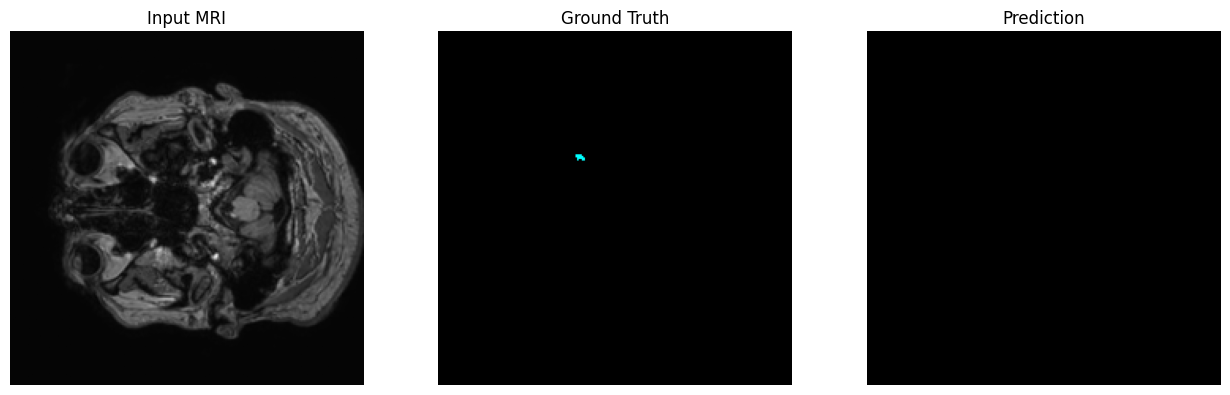

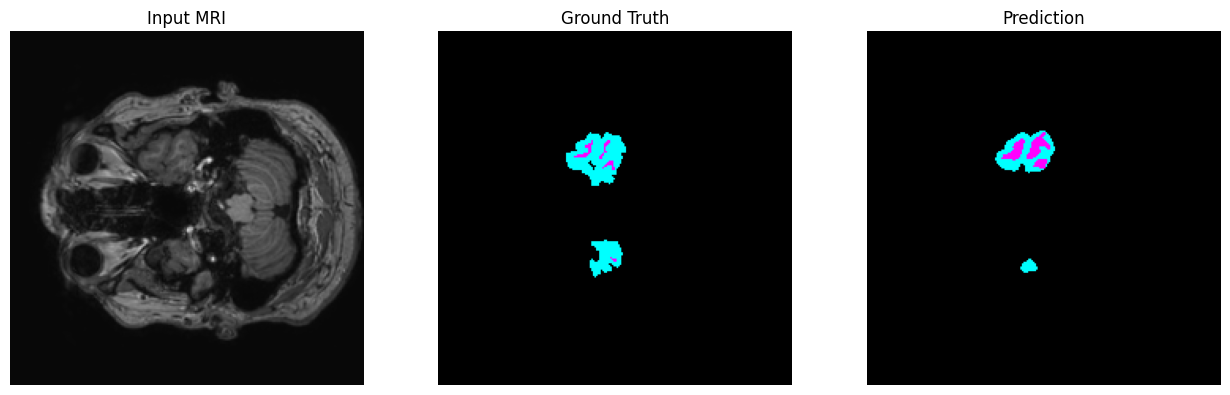

Prediction after epoch 10


Epoch 10: val_iou_score_multiclass improved from 0.32721 to 0.32771, saving model to best_model_vgg16unet_mrbrains.keras

Epoch 10: finished saving model to best_model_vgg16unet_mrbrains.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - csf_iou: 0.2262 - dice_coefficient_multiclass: 0.3449 - gm_iou: 1.9423e-05 - iou_score_multiclass: 0.2593 - loss: 1.0379 - pixel_accuracy_multiclass: 0.9818 - wm_iou: 0.0975 - val_csf_iou: 0.2993 - val_dice_coefficient_multiclass: 0.4400 - val_gm_iou: 0.0034 - val_iou_score_multiclass: 0.3277 - val_loss: 1.0082 - val_pixel_accuracy_multiclass: 0.9618 - val_wm_iou: 0.3116 - learning_rate: 1.0000e-04
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - csf_iou: 0.3197 - dice_coefficient_multiclass: 0.4373 - gm_iou: 0.0074 - iou_score_multiclass: 0.3421 - loss: 0.9195 - pixel_accuracy_multiclass: 0.9592 - wm_iou: 0.2872
Epoch 11: val_iou_score_multiclass improved from 0.32771 to 0.36141, saving model to best_model_vgg16unet_mr

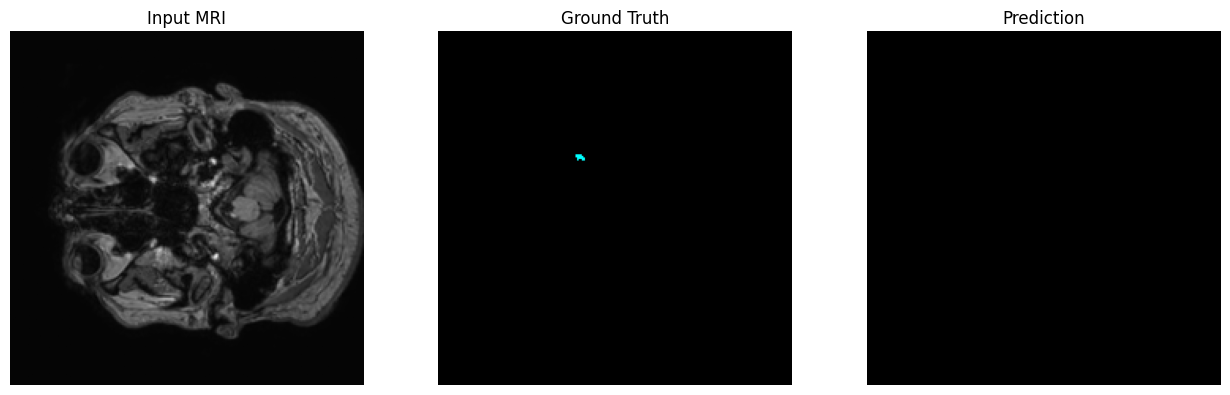

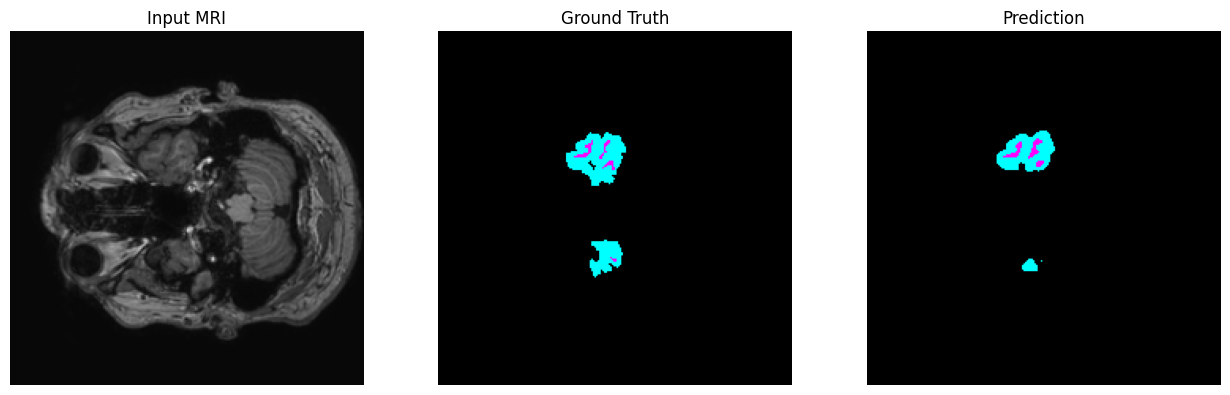

Prediction after epoch 20


Epoch 20: val_iou_score_multiclass improved from 0.43334 to 0.43420, saving model to best_model_vgg16unet_mrbrains.keras

Epoch 20: finished saving model to best_model_vgg16unet_mrbrains.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - csf_iou: 0.3503 - dice_coefficient_multiclass: 0.4264 - gm_iou: 2.9558e-05 - iou_score_multiclass: 0.3348 - loss: 0.7972 - pixel_accuracy_multiclass: 0.9860 - wm_iou: 0.1650 - val_csf_iou: 0.4231 - val_dice_coefficient_multiclass: 0.5387 - val_gm_iou: 0.0104 - val_iou_score_multiclass: 0.4342 - val_loss: 0.6851 - val_pixel_accuracy_multiclass: 0.9656 - val_wm_iou: 0.4559 - learning_rate: 1.0000e-04
Epoch 21/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - csf_iou: 0.4114 - dice_coefficient_multiclass: 0.4965 - gm_iou: 0.0155 - iou_score_multiclass: 0.4048 - loss: 0.7389 - pixel_accuracy_multiclass: 0.9682 - wm_iou: 0.3566
Epoch 21: val_iou_score_multiclass improved from 0.43420 to 0.44900, saving model to best_model_vgg16unet_mr

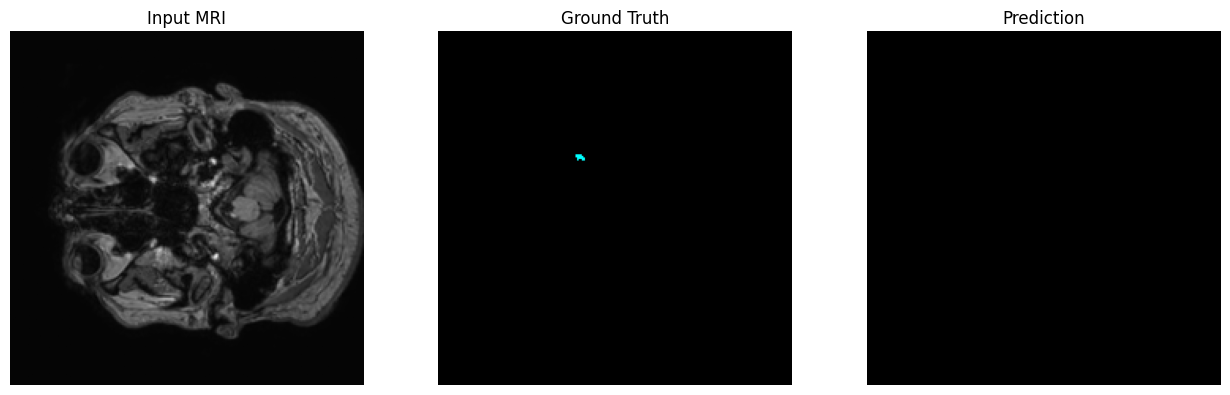

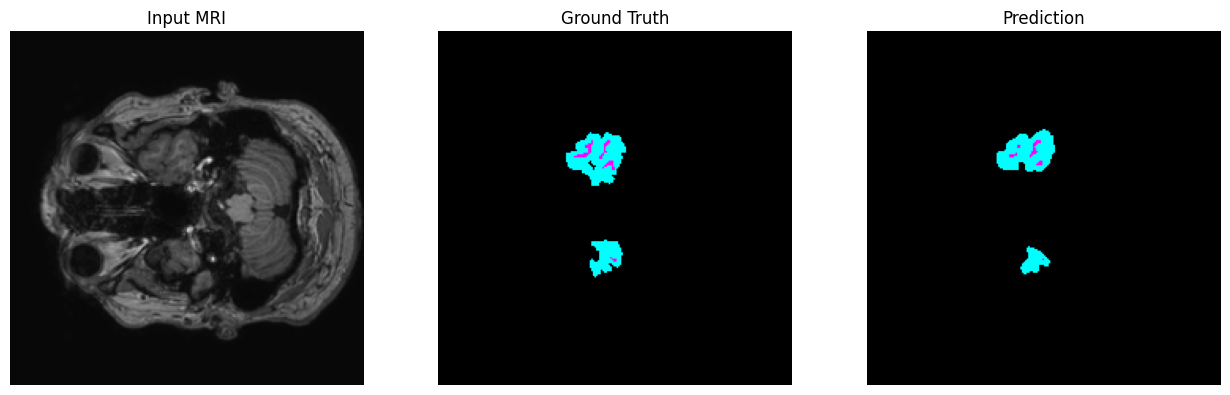

Prediction after epoch 30


Epoch 30: val_iou_score_multiclass did not improve from 0.48429
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - csf_iou: 0.4344 - dice_coefficient_multiclass: 0.4729 - gm_iou: 4.1965e-05 - iou_score_multiclass: 0.3813 - loss: 0.6823 - pixel_accuracy_multiclass: 0.9876 - wm_iou: 0.2130 - val_csf_iou: 0.5210 - val_dice_coefficient_multiclass: 0.5816 - val_gm_iou: 0.0260 - val_iou_score_multiclass: 0.4810 - val_loss: 0.5859 - val_pixel_accuracy_multiclass: 0.9692 - val_wm_iou: 0.4852 - learning_rate: 1.0000e-04
Epoch 31/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - csf_iou: 0.4702 - dice_coefficient_multiclass: 0.5401 - gm_iou: 0.0375 - iou_score_multiclass: 0.4492 - loss: 0.6369 - pixel_accuracy_multiclass: 0.9708 - wm_iou: 0.4062
Epoch 31: val_iou_score_multiclass improved from 0.48429 to 0.49196, saving model to best_model_vgg16unet_mrbrains.keras

Epoch 31: finished saving model to best_model_vgg16unet_mrbrains.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 313ms/step - 

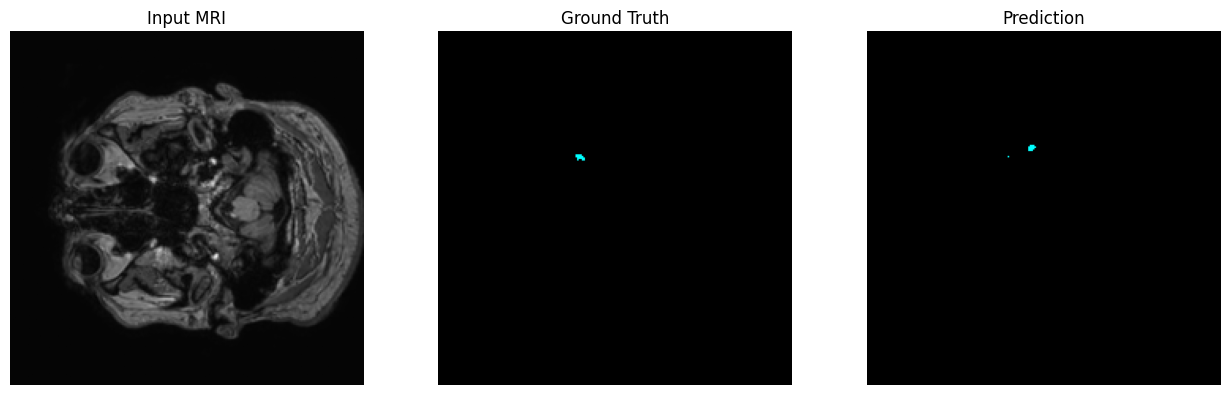

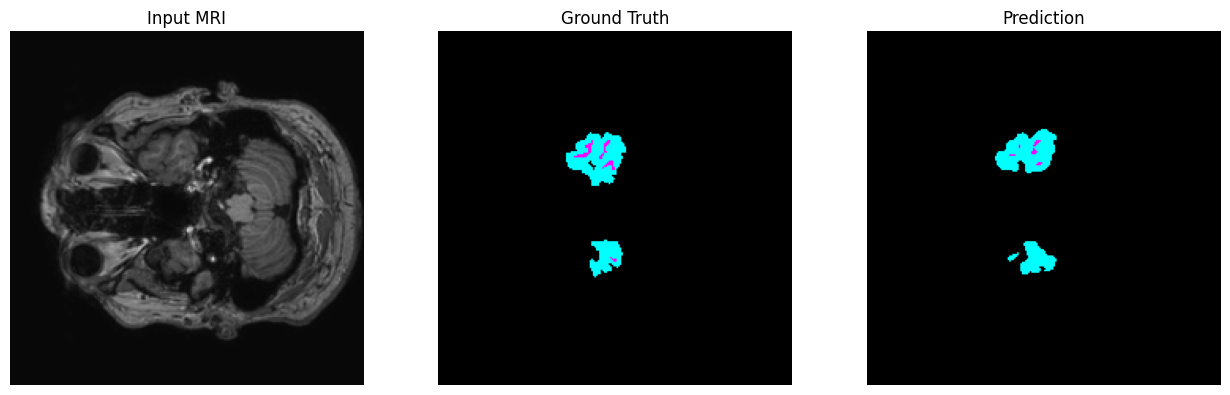

Prediction after epoch 40


Epoch 40: val_iou_score_multiclass did not improve from 0.52546
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - csf_iou: 0.4999 - dice_coefficient_multiclass: 0.5154 - gm_iou: 6.0775e-05 - iou_score_multiclass: 0.4241 - loss: 0.5972 - pixel_accuracy_multiclass: 0.9887 - wm_iou: 0.2818 - val_csf_iou: 0.5809 - val_dice_coefficient_multiclass: 0.6200 - val_gm_iou: 0.0528 - val_iou_score_multiclass: 0.5217 - val_loss: 0.5184 - val_pixel_accuracy_multiclass: 0.9717 - val_wm_iou: 0.5316 - learning_rate: 1.0000e-04
Epoch 41/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - csf_iou: 0.5161 - dice_coefficient_multiclass: 0.5784 - gm_iou: 0.0693 - iou_score_multiclass: 0.4874 - loss: 0.5606 - pixel_accuracy_multiclass: 0.9727 - wm_iou: 0.4491
Epoch 41: val_iou_score_multiclass improved from 0.52546 to 0.52674, saving model to best_model_vgg16unet_mrbrains.keras

Epoch 41: finished saving model to best_model_vgg16unet_mrbrains.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 311ms/step - c

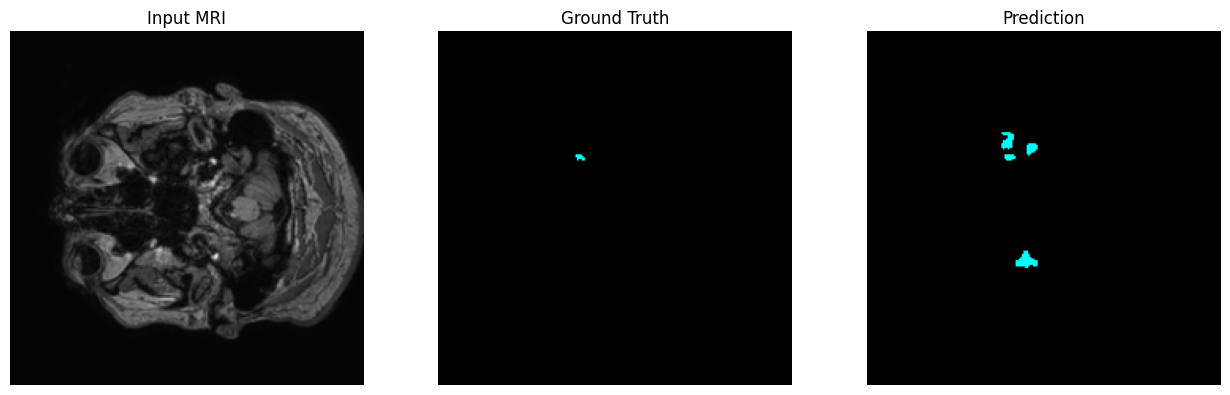

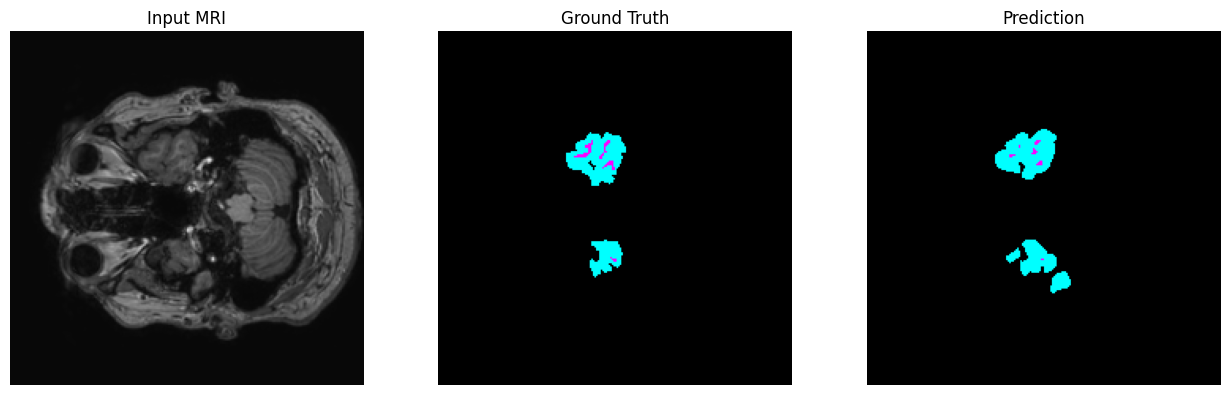

Prediction after epoch 50


Epoch 50: val_iou_score_multiclass did not improve from 0.55907
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - csf_iou: 0.5437 - dice_coefficient_multiclass: 0.5491 - gm_iou: 8.6273e-05 - iou_score_multiclass: 0.4592 - loss: 0.5401 - pixel_accuracy_multiclass: 0.9888 - wm_iou: 0.3548 - val_csf_iou: 0.6166 - val_dice_coefficient_multiclass: 0.6492 - val_gm_iou: 0.0729 - val_iou_score_multiclass: 0.5539 - val_loss: 0.4763 - val_pixel_accuracy_multiclass: 0.9729 - val_wm_iou: 0.5863 - learning_rate: 1.0000e-04
Epoch 51/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - csf_iou: 0.5566 - dice_coefficient_multiclass: 0.6096 - gm_iou: 0.0971 - iou_score_multiclass: 0.5194 - loss: 0.5026 - pixel_accuracy_multiclass: 0.9748 - wm_iou: 0.4876
Epoch 51: val_iou_score_multiclass improved from 0.55907 to 0.56165, saving model to best_model_vgg16unet_mrbrains.keras

Epoch 51: finished saving model to best_model_vgg16unet_mrbrains.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 310ms/step - c

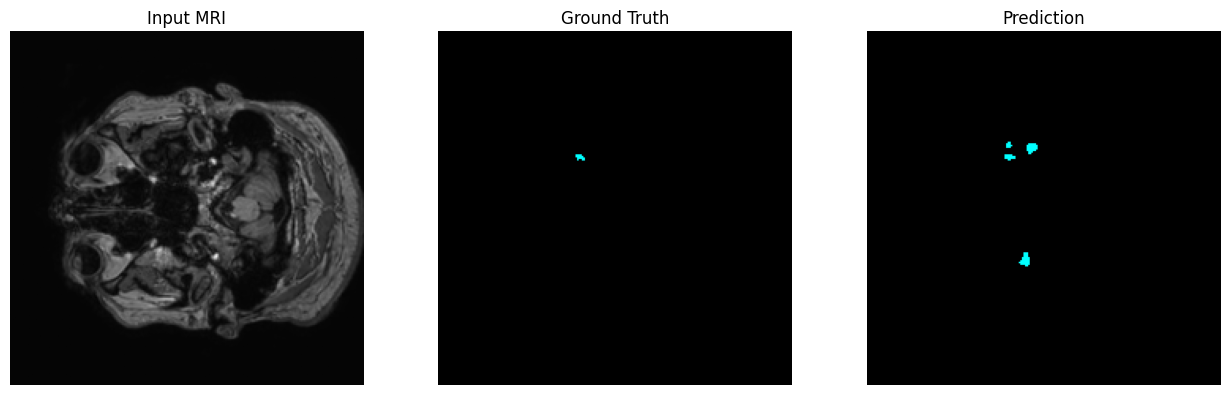

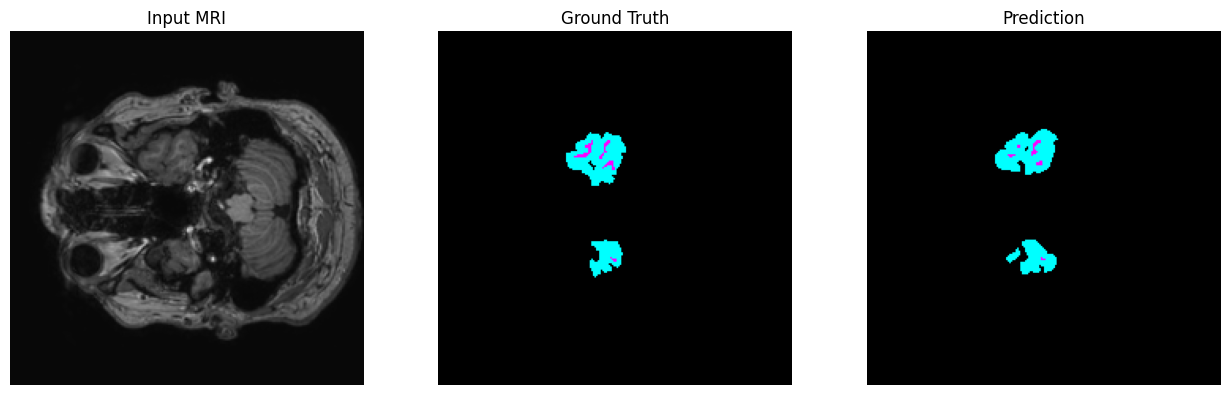

Prediction after epoch 60


Epoch 60: val_iou_score_multiclass did not improve from 0.58426
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - csf_iou: 0.5837 - dice_coefficient_multiclass: 0.5755 - gm_iou: 1.1963e-04 - iou_score_multiclass: 0.4887 - loss: 0.4946 - pixel_accuracy_multiclass: 0.9892 - wm_iou: 0.4166 - val_csf_iou: 0.6414 - val_dice_coefficient_multiclass: 0.6748 - val_gm_iou: 0.1033 - val_iou_score_multiclass: 0.5806 - val_loss: 0.4351 - val_pixel_accuracy_multiclass: 0.9742 - val_wm_iou: 0.6253 - learning_rate: 1.0000e-04
Epoch 61/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - csf_iou: 0.5883 - dice_coefficient_multiclass: 0.6358 - gm_iou: 0.1248 - iou_score_multiclass: 0.5465 - loss: 0.4609 - pixel_accuracy_multiclass: 0.9755 - wm_iou: 0.5230
Epoch 61: val_iou_score_multiclass did not improve from 0.58426
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 282ms/step - csf_iou: 0.5783 - dice_coefficient_multiclass: 0.6310 - gm_iou: 0.1176 - iou_score_multiclass: 0.5431 - loss: 0.4709 - pixel_accur

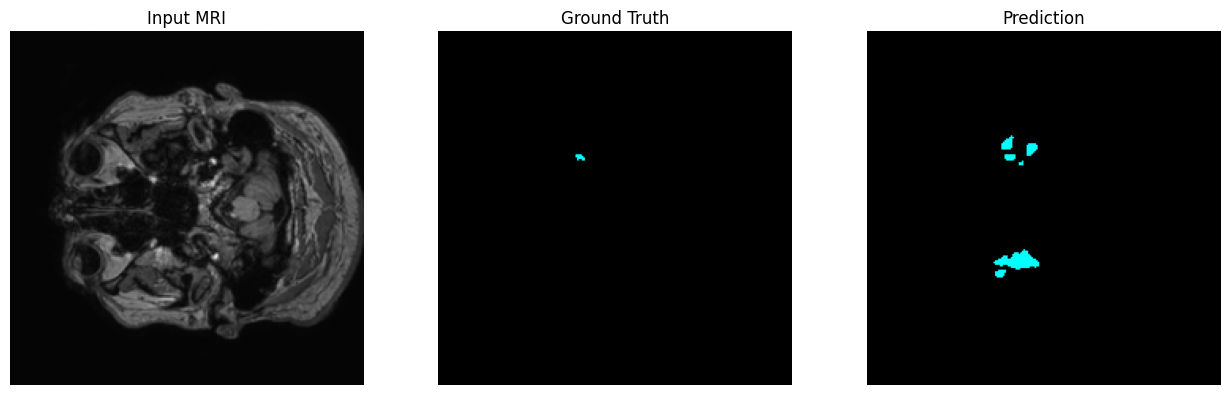

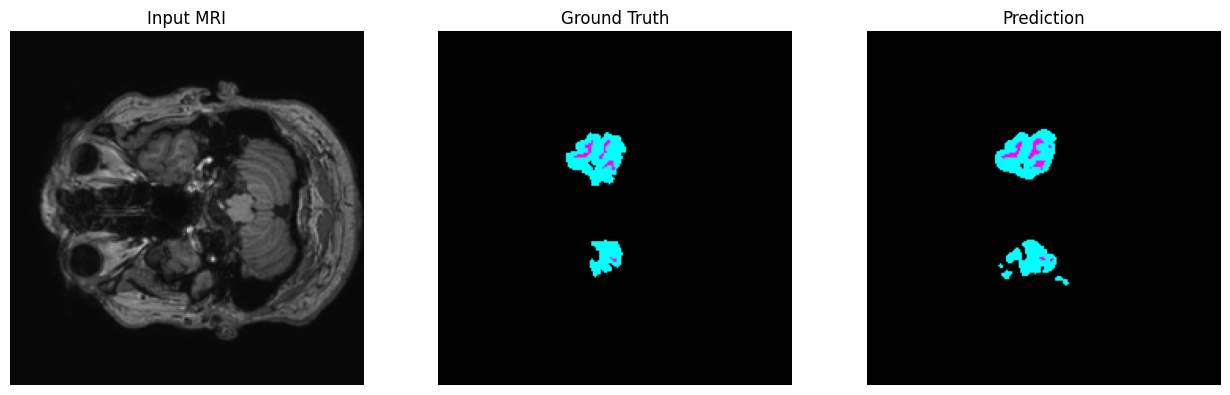

Prediction after epoch 70


Epoch 70: val_iou_score_multiclass did not improve from 0.60286
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - csf_iou: 0.6063 - dice_coefficient_multiclass: 0.5952 - gm_iou: 1.6984e-04 - iou_score_multiclass: 0.5115 - loss: 0.4670 - pixel_accuracy_multiclass: 0.9892 - wm_iou: 0.4742 - val_csf_iou: 0.6561 - val_dice_coefficient_multiclass: 0.6957 - val_gm_iou: 0.1375 - val_iou_score_multiclass: 0.6011 - val_loss: 0.4193 - val_pixel_accuracy_multiclass: 0.9738 - val_wm_iou: 0.6507 - learning_rate: 1.0000e-04
Epoch 71/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - csf_iou: 0.6087 - dice_coefficient_multiclass: 0.6554 - gm_iou: 0.1504 - iou_score_multiclass: 0.5669 - loss: 0.4315 - pixel_accuracy_multiclass: 0.9760 - wm_iou: 0.5493
Epoch 71: val_iou_score_multiclass improved from 0.60286 to 0.60647, saving model to best_model_vgg16unet_mrbrains.keras

Epoch 71: finished saving model to best_model_vgg16unet_mrbrains.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 308ms/step - c

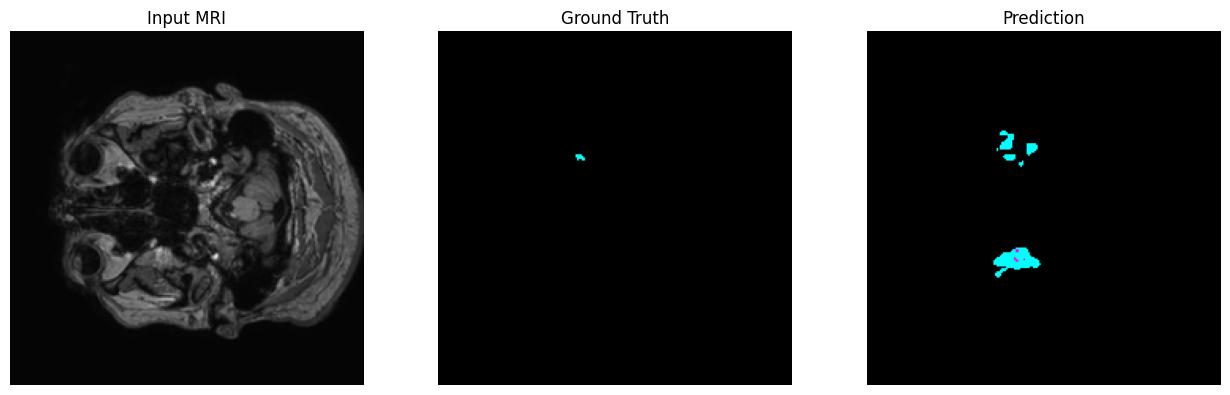

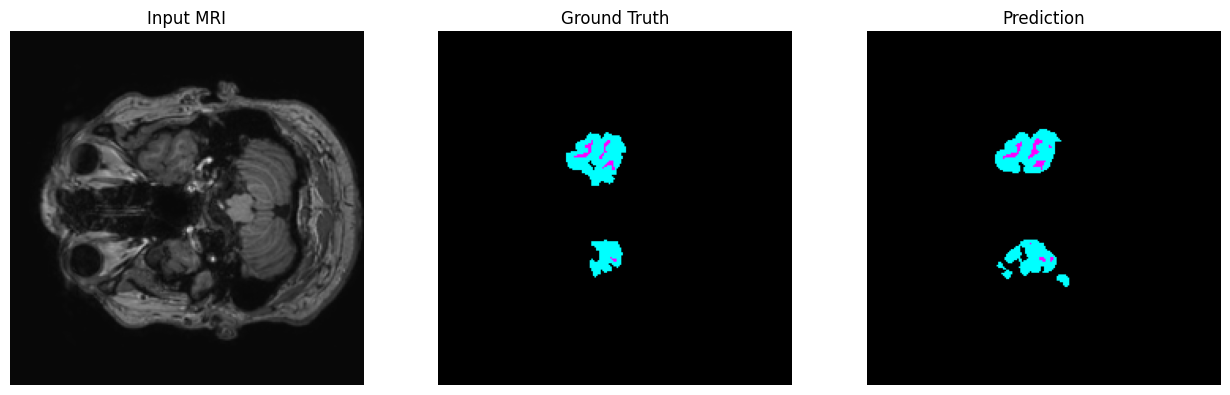

Prediction after epoch 80


Epoch 80: val_iou_score_multiclass did not improve from 0.62071
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - csf_iou: 0.6291 - dice_coefficient_multiclass: 0.6116 - gm_iou: 2.2791e-04 - iou_score_multiclass: 0.5316 - loss: 0.4406 - pixel_accuracy_multiclass: 0.9896 - wm_iou: 0.5241 - val_csf_iou: 0.6623 - val_dice_coefficient_multiclass: 0.7140 - val_gm_iou: 0.1682 - val_iou_score_multiclass: 0.6207 - val_loss: 0.3823 - val_pixel_accuracy_multiclass: 0.9752 - val_wm_iou: 0.6858 - learning_rate: 5.0000e-05
Epoch 81/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - csf_iou: 0.6352 - dice_coefficient_multiclass: 0.6753 - gm_iou: 0.1782 - iou_score_multiclass: 0.5889 - loss: 0.4014 - pixel_accuracy_multiclass: 0.9774 - wm_iou: 0.5760
Epoch 81: val_iou_score_multiclass improved from 0.62071 to 0.62113, saving model to best_model_vgg16unet_mrbrains.keras

Epoch 81: finished saving model to best_model_vgg16unet_mrbrains.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 309ms/step - c

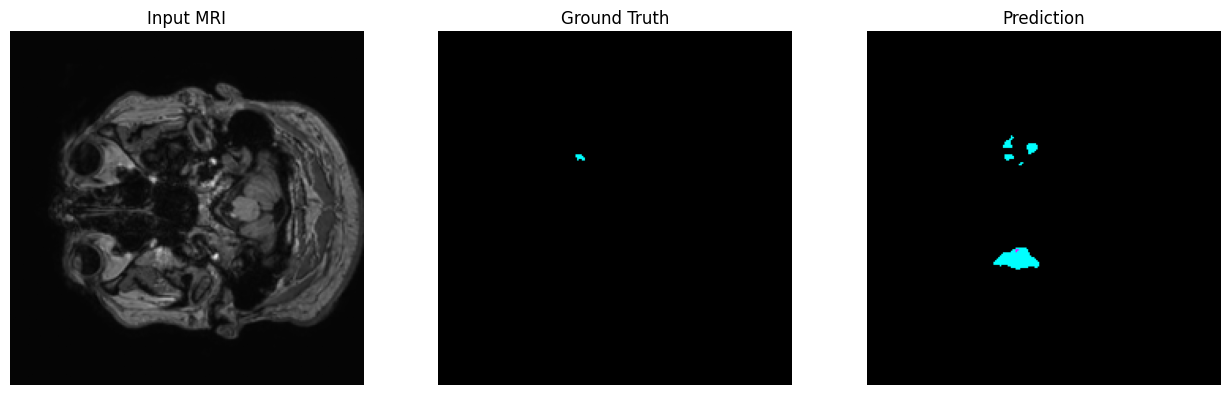

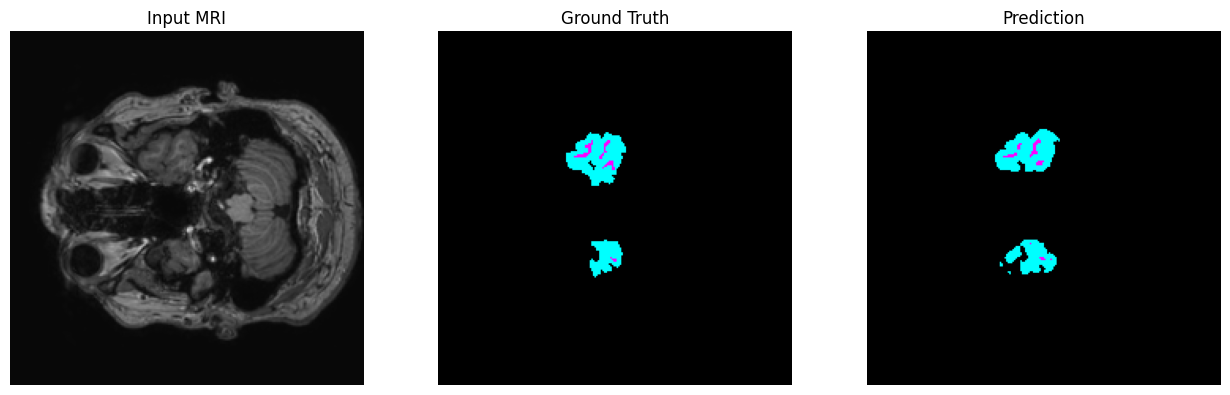

Prediction after epoch 90


Epoch 90: val_iou_score_multiclass did not improve from 0.62942
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - csf_iou: 0.6530 - dice_coefficient_multiclass: 0.6187 - gm_iou: 2.6666e-04 - iou_score_multiclass: 0.5409 - loss: 0.4275 - pixel_accuracy_multiclass: 0.9903 - wm_iou: 0.5343 - val_csf_iou: 0.6690 - val_dice_coefficient_multiclass: 0.7218 - val_gm_iou: 0.1931 - val_iou_score_multiclass: 0.6273 - val_loss: 0.3646 - val_pixel_accuracy_multiclass: 0.9754 - val_wm_iou: 0.6779 - learning_rate: 5.0000e-05
Epoch 91/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - csf_iou: 0.6483 - dice_coefficient_multiclass: 0.6857 - gm_iou: 0.1931 - iou_score_multiclass: 0.6004 - loss: 0.3868 - pixel_accuracy_multiclass: 0.9779 - wm_iou: 0.5912
Epoch 91: val_iou_score_multiclass improved from 0.62942 to 0.63278, saving model to best_model_vgg16unet_mrbrains.keras

Epoch 91: finished saving model to best_model_vgg16unet_mrbrains.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 306ms/step - c

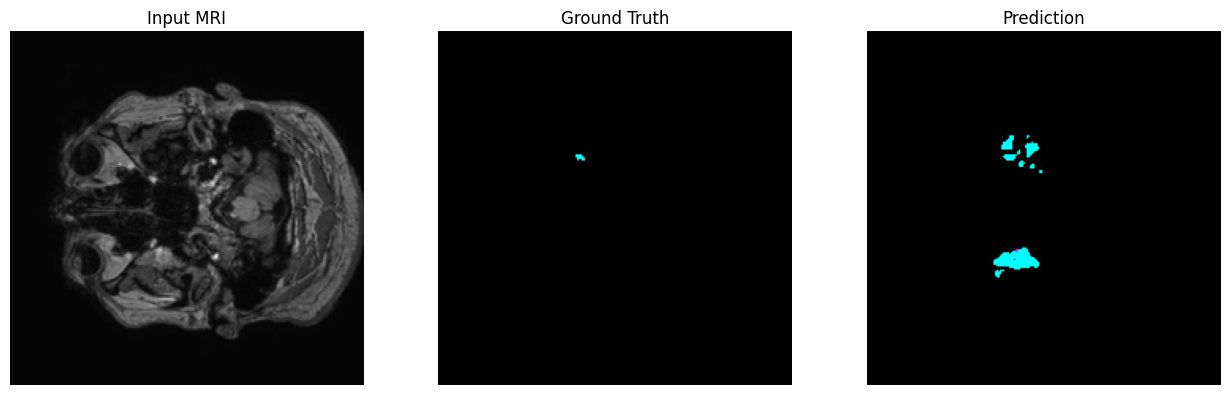

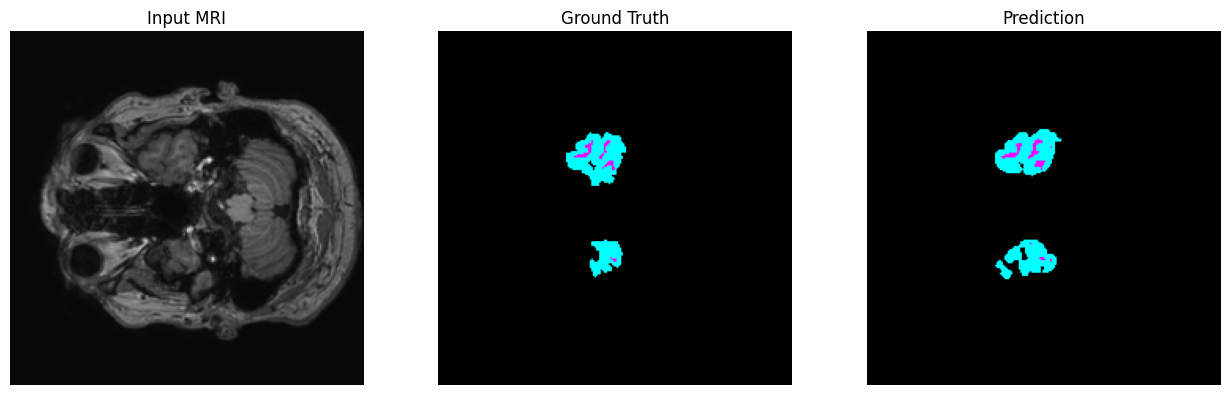

Prediction after epoch 100


Epoch 100: val_iou_score_multiclass did not improve from 0.63791
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - csf_iou: 0.6470 - dice_coefficient_multiclass: 0.6233 - gm_iou: 3.1792e-04 - iou_score_multiclass: 0.5465 - loss: 0.4239 - pixel_accuracy_multiclass: 0.9896 - wm_iou: 0.5604 - val_csf_iou: 0.6746 - val_dice_coefficient_multiclass: 0.7308 - val_gm_iou: 0.2081 - val_iou_score_multiclass: 0.6372 - val_loss: 0.3552 - val_pixel_accuracy_multiclass: 0.9754 - val_wm_iou: 0.6953 - learning_rate: 5.0000e-05

Training time: 13.0 min


In [21]:
steps_per_epoch  = max(1, len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE)
validation_steps = max(1, len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE)

print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()
history = model.fit(
    train_dataset, validation_data=test_dataset, epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch, validation_steps=validation_steps,
    callbacks=callbacks_list
)
print(f'\nTraining time: {(time.time()-start_time)/60:.1f} min')

## 13. Training Graphs

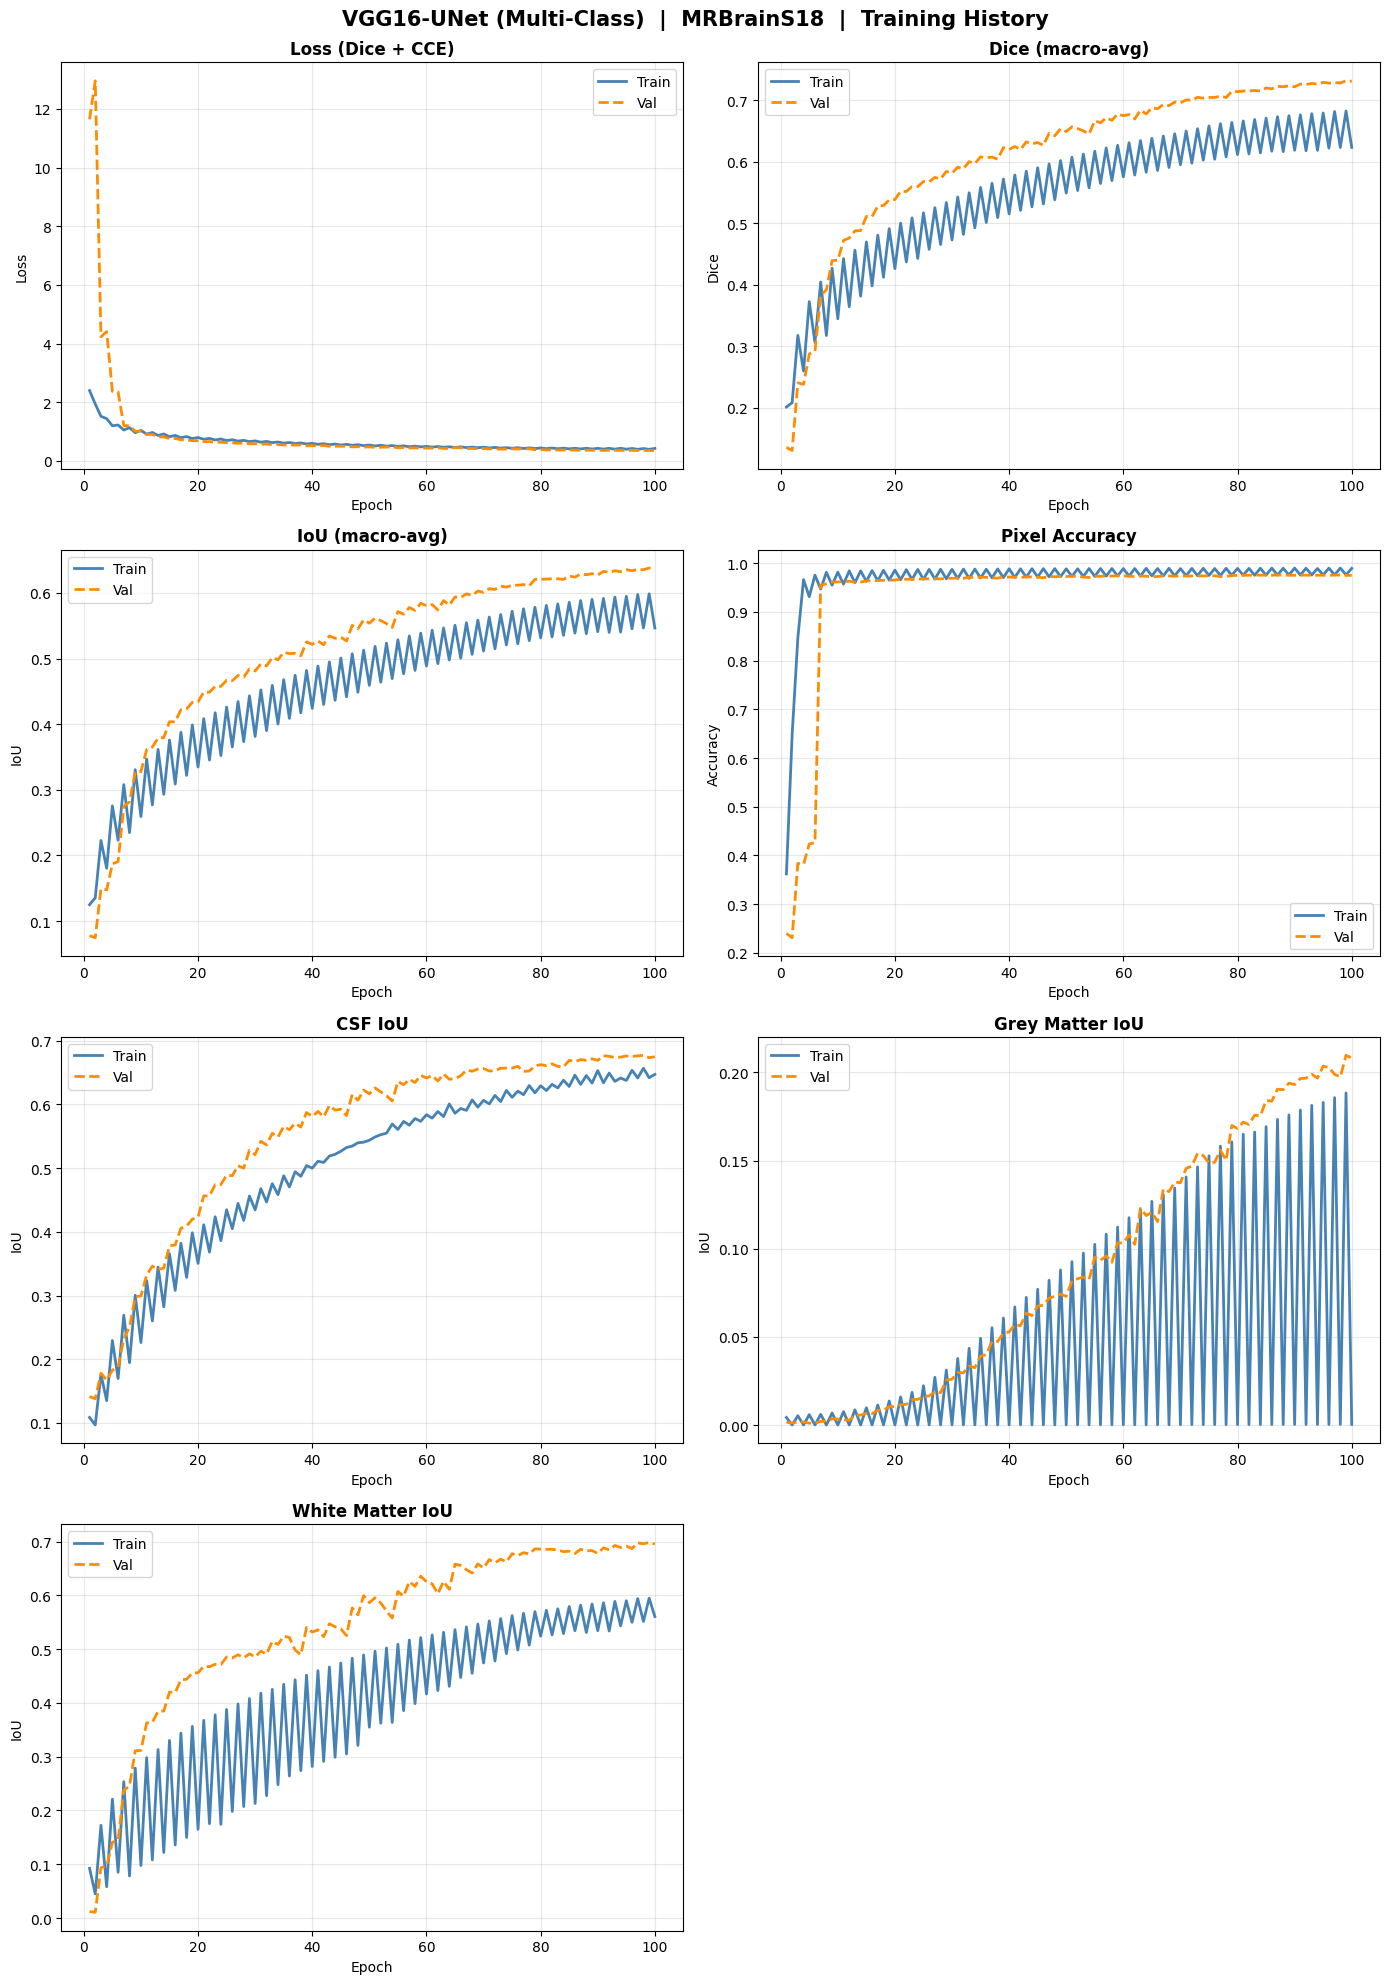

Plot saved ✓


In [22]:
H = history.history

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('VGG16-UNet (Multi-Class)  |  MRBrainS18  |  Training History',
             fontsize=15, fontweight='bold', y=0.99)

plot_specs = [
    ('loss', 'val_loss', 'Loss (Dice + CCE)', 'Loss'),
    ('dice_coefficient_multiclass', 'val_dice_coefficient_multiclass', 'Dice (macro-avg)', 'Dice'),
    ('iou_score_multiclass', 'val_iou_score_multiclass', 'IoU (macro-avg)', 'IoU'),
    ('pixel_accuracy_multiclass', 'val_pixel_accuracy_multiclass', 'Pixel Accuracy', 'Accuracy'),
    ('csf_iou', 'val_csf_iou', 'CSF IoU', 'IoU'),
    ('gm_iou', 'val_gm_iou', 'Grey Matter IoU', 'IoU'),
    ('wm_iou', 'val_wm_iou', 'White Matter IoU', 'IoU'),
]

for ax, (tk, vk, title, ylabel) in zip(axes.flatten(), plot_specs):
    er = range(1, len(H[tk]) + 1)
    ax.plot(er, H[tk], label='Train', color='steelblue', linewidth=2)
    ax.plot(er, H[vk], label='Val', color='darkorange', linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.savefig('training_history_vgg16unet_mrbrains.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')

## 14. Best & Average Metrics Table

In [23]:
metric_spec = [
    ('Loss', 'loss', 'min'),
    ('Dice (macro-avg)', 'dice_coefficient_multiclass', 'max'),
    ('IoU (macro-avg)', 'iou_score_multiclass', 'max'),
    ('Pixel Accuracy', 'pixel_accuracy_multiclass', 'max'),
    ('CSF IoU', 'csf_iou', 'max'),
    ('Grey Matter IoU', 'gm_iou', 'max'),
    ('White Matter IoU', 'wm_iou', 'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key], dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({'Metric': disp, 'Train Best': pick(tr), 'Train Avg': tr.mean(),
                 'Val Best': pick(va), 'Val Avg': va.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)

print('=' * 68)
print('   BEST & AVERAGE METRICS  —  VGG16-UNet Multi-Class  |  MRBrainS18')
print('=' * 68)
print(report.to_string())
print('=' * 68)
best_epoch = int(np.argmax(H['val_iou_score_multiclass'])) + 1
print(f'\nBest Val IoU (macro-avg): {max(H["val_iou_score_multiclass"]):.4f}  (epoch {best_epoch})')
print(f'Best Val CSF IoU         : {max(H["val_csf_iou"]):.4f}')
print(f'Best Val Grey Matter IoU : {max(H["val_gm_iou"]):.4f}')
print(f'Best Val White Matter IoU: {max(H["val_wm_iou"]):.4f}')
report

   BEST & AVERAGE METRICS  —  VGG16-UNet Multi-Class  |  MRBrainS18
                  Train Best  Train Avg  Val Best  Val Avg
Metric                                                    
Loss                  0.3932     0.6366    0.3544   0.8688
Dice (macro-avg)      0.6825     0.5453    0.7315   0.6114
IoU (macro-avg)       0.5987     0.4582    0.6379   0.5144
Pixel Accuracy        0.9903     0.9681    0.9759   0.9339
CSF IoU               0.6567     0.5004    0.6770   0.5508
Grey Matter IoU       0.1883     0.0450    0.2097   0.0885
White Matter IoU      0.5946     0.3995    0.6980   0.5406

Best Val IoU (macro-avg): 0.6379  (epoch 99)
Best Val CSF IoU         : 0.6770
Best Val Grey Matter IoU : 0.2097
Best Val White Matter IoU: 0.6980


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,0.3932,0.6366,0.3544,0.8688
Dice (macro-avg),0.6825,0.5453,0.7315,0.6114
IoU (macro-avg),0.5987,0.4582,0.6379,0.5144
Pixel Accuracy,0.9903,0.9681,0.9759,0.9339
CSF IoU,0.6567,0.5004,0.6770,0.5508
Grey Matter IoU,0.1883,0.0450,0.2097,0.0885
White Matter IoU,0.5946,0.3995,0.6980,0.5406


## 15. Load Best Model & Final Evaluation

In [24]:
best_model = tf.keras.models.load_model(
    'best_model_vgg16unet_mrbrains.keras',
    custom_objects={
        'combined_loss_multiclass': combined_loss_multiclass,
        'dice_coefficient_multiclass': dice_coefficient_multiclass,
        'iou_score_multiclass': iou_score_multiclass,
        'pixel_accuracy_multiclass': pixel_accuracy_multiclass,
        'csf_iou': csf_iou, 'gm_iou': gm_iou, 'wm_iou': wm_iou,
    }
)
print('Best model loaded ✓')

Best model loaded ✓


In [25]:
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict = dict(zip(best_model.metrics_names, test_results))

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (VGG16-UNet | MRBrainS18)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {k:35s}: {v:.4f}')
print('=' * 60)

pd.DataFrame([{
    'Model': 'VGG16-UNet (MRBrainS18)',
    'IoU (macro)': round(test_dict.get('iou_score_multiclass', float('nan')), 4),
    'Dice (macro)': round(test_dict.get('dice_coefficient_multiclass', float('nan')), 4),
    'CSF IoU': round(test_dict.get('csf_iou', float('nan')), 4),
    'GM IoU': round(test_dict.get('gm_iou', float('nan')), 4),
    'WM IoU': round(test_dict.get('wm_iou', float('nan')), 4),
    'Pixel Accuracy': round(test_dict.get('pixel_accuracy_multiclass', float('nan')), 4),
}]).set_index('Model')

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - csf_iou: 0.6733 - dice_coefficient_multiclass: 0.7315 - gm_iou: 0.2097 - iou_score_multiclass: 0.6379 - loss: 0.3544 - pixel_accuracy_multiclass: 0.9752 - wm_iou: 0.6980

  FINAL TEST-SET METRICS  (VGG16-UNet | MRBrainS18)
  loss                               : 0.3544
  compile_metrics                    : 0.7315


,IoU (macro),Dice (macro),CSF IoU,GM IoU,WM IoU,Pixel Accuracy
Model,,,,,,
VGG16-UNet (MRBrainS18),NaN,NaN,NaN,NaN,NaN,NaN


## 16. Test Predictions Visualization

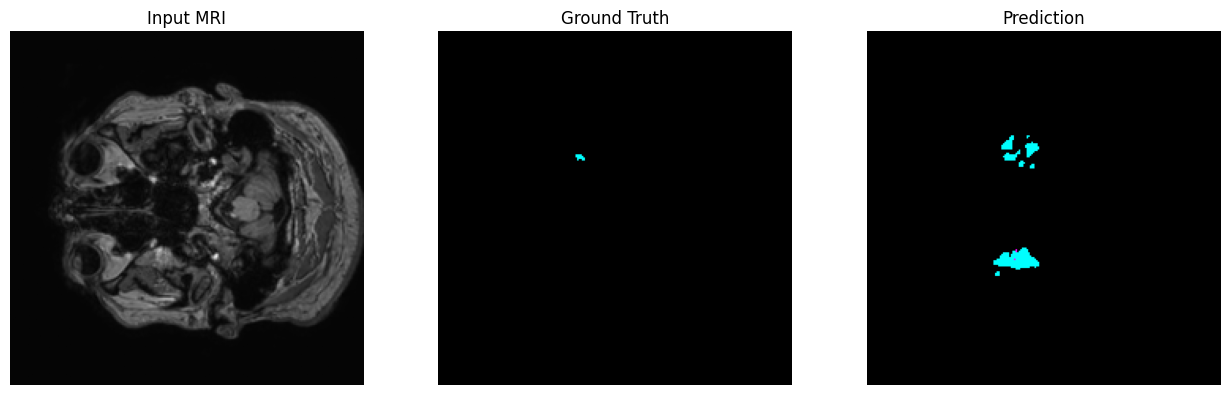

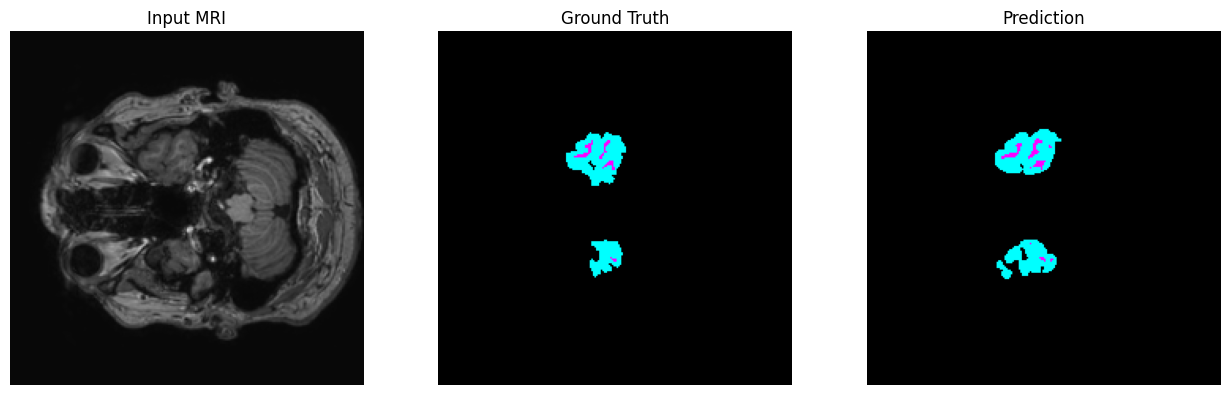

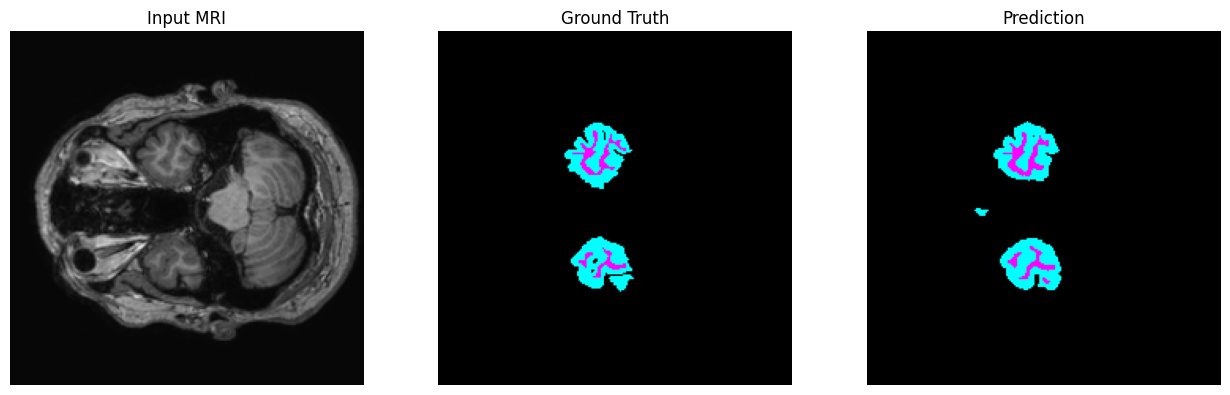

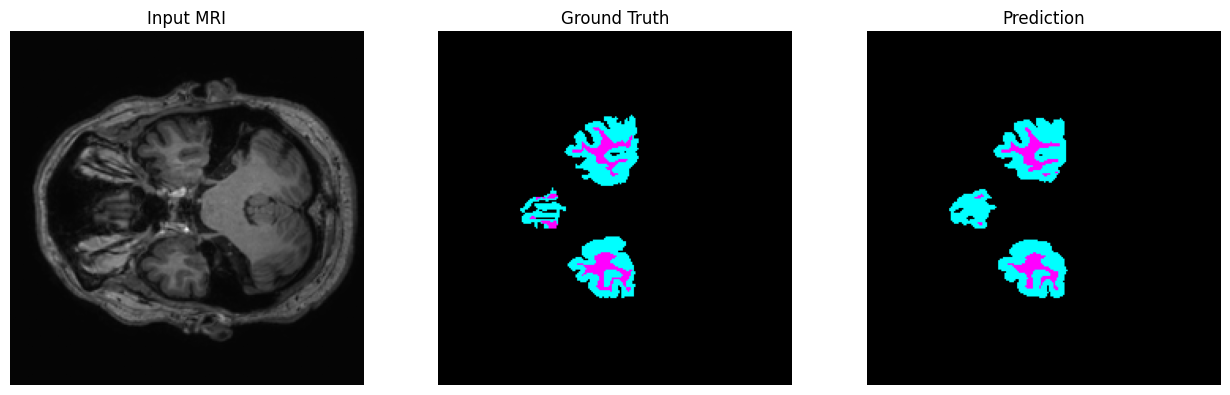

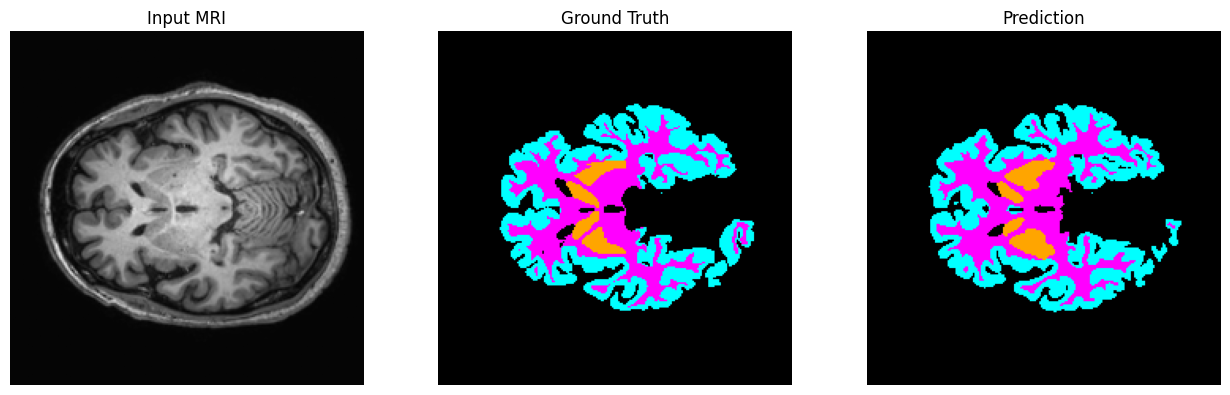

In [26]:
show_predictions(test_dataset, num=5, model_to_use=best_model)

## 17. Save Final Model

In [27]:
best_model.save('mrbrains_vgg16_unet_multiclass_final.keras')
print('Model saved ✓')

Model saved ✓
